In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchmetrics as tm
from torch.utils.data import TensorDataset

In [2]:
seed = 42
device = "cuda"

root_path = "/home/stefan/ioai-prep/kits/roai-2026/fox"

# Subtask 1

In [3]:
unlabeled_df = pd.read_csv(f"{root_path}/unlabeled_data.csv")

unlabeled_df.head()

,id,text
0,145,hwygcitunxy txaqhsbspp wppyqfewq efxtky sbafp ...
1,6891,efxtky hhumxi fjfuhwt fdfpxccspynq wppyqfewq w...
2,14281,efxtky xpylmbi wppyqfewq laeoxdw glhwq rjeegtr...
3,30205,eufs tfusmgrcm ehdho jzinuxcc qiyicseqlpa wppy...
4,14413,sbafp mqndwkadzsw ffatkgedh qbaymfaw wppyqfewq...


In [4]:
vocab_words = set()

for i in tqdm(range(len(unlabeled_df))):
    row = unlabeled_df.iloc[i]
    sent = row["text"].split()
    for s in sent:
        vocab_words.add(s)

vocab_words = list(vocab_words)
vocab_words[:3]

100%|██████████| 36000/36000 [00:00<00:00, 36761.82it/s]


['lxkvksiig', 'gsxhdtx', 'pgdyugxyhge']

In [5]:
subtask1 = [len(vocab_words)]
subtask1

[3529]

In [6]:
vocab_words = sorted(list(vocab_words))
w2i = {w: i + 1 for i, w in enumerate(vocab_words)}
w2i["<PAD>"] = 0
i2w = {i: w for w, i in w2i.items()}


def tokenize(sent):
    sent = sent.split()
    return np.array([w2i.get(w, 0) for w in sent])

def detokenize(tsent):
    sent = tsent.tolist()
    sent = [i2w[i] for i in sent]
    return " ".join(sent)

sample = unlabeled_df.iloc[0]["text"]
print(sample)
print(detokenize(tokenize(sample)))

hwygcitunxy txaqhsbspp wppyqfewq efxtky sbafp tzdfeb wppyqfewq
hwygcitunxy txaqhsbspp wppyqfewq efxtky sbafp tzdfeb wppyqfewq


# Subtask 2

## Data

In [7]:
train_df = pd.read_csv(f"{root_path}/train_data.csv")
test_df = pd.read_csv(f"{root_path}/test_data.csv")
train_df.head()

,id,text,label
0,556,ptpn sbafp wqpe vsuowfut adq xlxu jzinuxcc xyv...,0
1,3492,ygeuek jzinuxcc xhz hoahlprmlf qtbaoovq ewr pq...,3
2,528,ygeuek xhz hoahlprmlf qtbaoovq ewr vnadrfte md...,0
3,3926,ptpn undfd aelkqwvhyrjh ptpn cxjcucs tq qqgxt ...,3
4,2990,ptpn undfd xpylmbi aelkqwvhyrjh ptpn cxjcucs t...,2


In [8]:
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=seed)

In [9]:
class FoxDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self.df["tokens"] = df["text"].map(tokenize)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tokens = torch.tensor(row["tokens"])

        label = torch.tensor([row["label"]]) if "label" in self.df.columns else None
        return tokens, label

    def __len__(self):
        return len(self.df)

In [10]:
def collate_fn(batch):
    tokens_list = [item[0] for item in batch]
    tokens_padded = pad_sequence(tokens_list, batch_first=True)

    if batch[0][1] is not None:
        labels = torch.stack([item[1] for item in batch])
        return tokens_padded, labels

    return tokens_padded


train_ds = FoxDataset(train_df)
val_ds = FoxDataset(val_df)
test_ds = FoxDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)

In [21]:
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([16, 10]), torch.Size([16, 1])]

## Pretraining

In [12]:
V = len(vocab_words)
emb_dim = 32
K = 15

In [13]:
sentences = [text.split() for text in unlabeled_df["text"].tolist()]

window = 5
pairs = []
for sent in tqdm(sentences, desc="Building skip-gram pairs"):
    for i, w in enumerate(sent):
        for j in range(max(0, i - window), min(len(sent), i + window + 1)):
            if i != j:
                pairs.append((w2i[w], w2i[sent[j]]))

pairs = torch.tensor(pairs, dtype=torch.long, device=device)

Building skip-gram pairs: 100%|██████████| 36000/36000 [00:00<00:00, 78005.95it/s]


In [14]:
word_counts = Counter(w for sent in sentences for w in sent)
freq = torch.tensor(
    [word_counts[w] for w in vocab_words], dtype=torch.float, device=device
)
freq = freq**0.75
freq /= freq.sum()

In [17]:
embedding = nn.Embedding(V + 1, emb_dim, padding_idx=0).to(device)
loss_fn = nn.CosineEmbeddingLoss(margin=0.5)
optimizer = optim.Adam(embedding.parameters(), lr=0.01)

loader = DataLoader(TensorDataset(pairs), batch_size=8192, shuffle=True)

In [ ]:
for epoch in range(5):
    total_loss = 0.0
    for (batch_embd,) in tqdm(loader, desc=f"Epoch {epoch+1}"):
        w, c_pos = batch_embd[:, 0], batch_embd[:, 1]

        neg_idx = torch.multinomial(freq, len(w) * K, replacement=True) + 1
        c_neg = neg_idx.view(len(w), K)

        v_w = embedding(w)
        v_pos = embedding(c_pos)
        v_neg = embedding(c_neg)

        pos_loss = loss_fn(v_w, v_pos, torch.ones(len(w), device=device))

        v_w_exp = v_w.unsqueeze(1).expand(-1, K, -1).reshape(-1, emb_dim)
        v_neg_flat = v_neg.reshape(-1, emb_dim)
        neg_loss = loss_fn(v_w_exp, v_neg_flat, -torch.ones(len(w) * K, device=device))

        loss = pos_loss + neg_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, loss: {total_loss:.2f}")

pretrained_embeddings = embedding.weight.detach().cpu()

Epoch 1: 100%|██████████| 183/183 [00:05<00:00, 33.05it/s]


Epoch 1, loss: 119.25


Epoch 2: 100%|██████████| 183/183 [00:05<00:00, 32.19it/s]


Epoch 2, loss: 75.06


Epoch 3: 100%|██████████| 183/183 [00:05<00:00, 31.39it/s]


Epoch 3, loss: 70.55


Epoch 4: 100%|██████████| 183/183 [00:06<00:00, 29.79it/s]


Epoch 4, loss: 64.40


Epoch 5: 100%|██████████| 183/183 [00:05<00:00, 32.58it/s]

Epoch 5, loss: 61.65


## Model

In [19]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.n_embd = 32
        self.vocab_size = len(vocab_words)

        self.embedding = nn.Embedding(self.vocab_size + 1, 32, padding_idx=0)
        self.embedding.weight.data[1:] = pretrained_embeddings[1:]
        self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(self.n_embd, self.n_embd, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Linear(self.n_embd * 2, 4)

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)
        embedded = self.dropout(self.embedding(x))
        output, _ = self.lstm(embedded)

        sum_output = torch.sum(output * mask, dim=1)
        count_output = torch.clamp(mask.sum(dim=1), min=1e-9)
        pooled = sum_output / count_output

        return self.fc(pooled)

In [22]:
model = Model().to(device)
model(batch[0].to(device)).shape

torch.Size([16, 4])

## Training

In [23]:
epochs = 2

optimizer = optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
f1 = tm.F1Score(task="multiclass", num_classes=4, average="macro").to(device)

In [24]:
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    for sent, label in tqdm(train_loader):
        sent, label = sent.to(device), label.squeeze().to(device)

        logits = model(sent)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    f1.reset()
    val_loss = 0.0
    for sent, label in tqdm(val_loader):
        sent, label = sent.to(device), label.squeeze().to(device)

        with torch.no_grad():
            logits = model(sent)
            loss = criterion(logits, label)

        f1(logits, label)
        val_loss += loss.item()

    running_loss /= len(train_loader)
    val_loss /= len(val_loader)
    print(
        f"epoch {epoch}: loss={running_loss:.3f}, val_loss={val_loss:.3f}, f1={f1.compute():.2f}"
    )

100%|██████████| 50/50 [00:00<00:00, 360.11it/s]


epoch 1: loss=0.994, val_loss=0.361, f1=0.95


100%|██████████| 50/50 [00:00<00:00, 345.19it/s]

epoch 2: loss=0.291, val_loss=0.189, f1=0.93


## Inference

100%|██████████| 125/125 [00:00<00:00, 772.31it/s]


<Axes: ylabel='Count'>

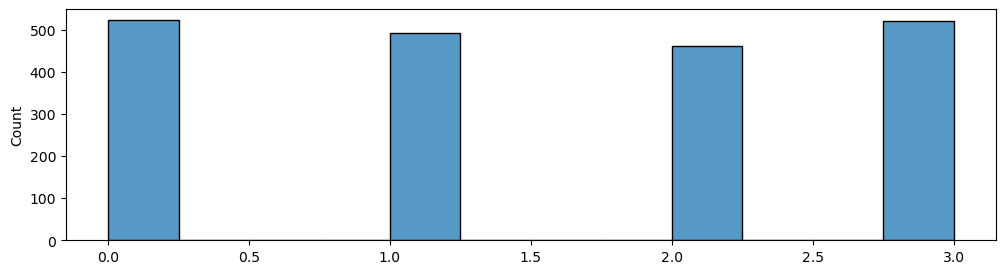

In [25]:
model.eval()

subtask2 = []

for tokens in tqdm(test_loader):
    tokens = tokens.to(device)
    with torch.no_grad():
        logits = model(tokens)
    ans = logits.argmax(-1).detach().cpu().tolist()
    subtask2.extend(ans)

plt.figure(figsize=(12, 3))
sns.histplot(subtask2)

# Submission

In [26]:
def build_sub(sid, ans):
    return pd.DataFrame({
        "datapointID": test_df["id"] if sid == 2 else 0,
        "subtaskID": sid,
        "answer": ans
    })

subtasks = [
    (1, subtask1),
    (2, subtask2)
]

submission = pd.concat([build_sub(sid, ans) for sid, ans in subtasks])

In [27]:
submission.head()

,datapointID,subtaskID,answer
0,0,1,3529
0,1964,2,3
1,1128,2,0
2,37,2,2
3,1819,2,1


In [28]:
submission.to_csv(f"{root_path}/sub_fox.csv", index=False)